# Top 10 best-selling and worst-selling products

### Methodology

- Grouping the orders by the product ID
- Counting the orders for each product
- Visualizing the data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('sample_superstore.xls')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,2026-12-30,2027-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,2026-12-30,2027-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279


In [11]:
df_count = (df.groupby(['Product ID', 'Sub-Category', 'Product Name'])
    .agg(
        Total_Quantity=('Quantity', 'sum'),
    )
    .sort_values('Total_Quantity', ascending=False)
)
df_count

,,,Total_Quantity
Product ID,Sub-Category,Product Name,
FUR-FU-10002501,Furnishings,Nu-Dell Executive Frame,84
OFF-BI-10001718,Binders,GBC DocuBind P50 Personal Binding Machine,72
OFF-BI-10001524,Binders,GBC Premium Transparent Covers with Diagonal Lined Pattern,67
TEC-PH-10001300,Phones,"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",64
FUR-CH-10002647,Chairs,"Situations Contoured Folding Chairs, 4/Set",64
...,...,...,...
FUR-BO-10002206,Bookcases,"Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order",1
TEC-MA-10003493,Machines,Penpower WorldCard Pro Card Scanner,1
OFF-PA-10000048,Paper,Xerox 20,1


In [12]:
df_best_products = df_count.head(10)
df_best_products

,,,Total_Quantity
Product ID,Sub-Category,Product Name,
FUR-FU-10002501,Furnishings,Nu-Dell Executive Frame,84
OFF-BI-10001718,Binders,GBC DocuBind P50 Personal Binding Machine,72
OFF-BI-10001524,Binders,GBC Premium Transparent Covers with Diagonal Lined Pattern,67
TEC-PH-10001300,Phones,"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",64
FUR-CH-10002647,Chairs,"Situations Contoured Folding Chairs, 4/Set",64
FUR-TA-10001095,Tables,Chromcraft Round Conference Tables,61
FUR-FU-10001979,Furnishings,Dana Halogen Swing-Arm Architect Lamp,60
FUR-CH-10003774,Chairs,"Global Wood Trimmed Manager's Task Chair, Khaki",59
FUR-CH-10004287,Chairs,SAFCO Arco Folding Chair,59


In [13]:
df_worst_products = df_count.tail(10)
df_worst_products

,,,Total_Quantity
Product ID,Sub-Category,Product Name,
TEC-AC-10003133,Accessories,Memorex Mini Travel Drive 4 GB USB 2.0 Flash Drive,2
OFF-PA-10002001,Paper,Xerox 1984,2
OFF-EN-10004206,Envelopes,Multimedia Mailers,2
TEC-PH-10004875,Phones,PNY Rapid USB Car Charger - Black,2
OFF-EN-10001749,Envelopes,Jiffy Padded Mailers with Self-Seal Closure,2
FUR-BO-10002206,Bookcases,"Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order",1
TEC-MA-10003493,Machines,Penpower WorldCard Pro Card Scanner,1
OFF-PA-10000048,Paper,Xerox 20,1
FUR-CH-10002317,Chairs,Global Enterprise Series Seating Low-Back Swivel/Tilt Chairs,1


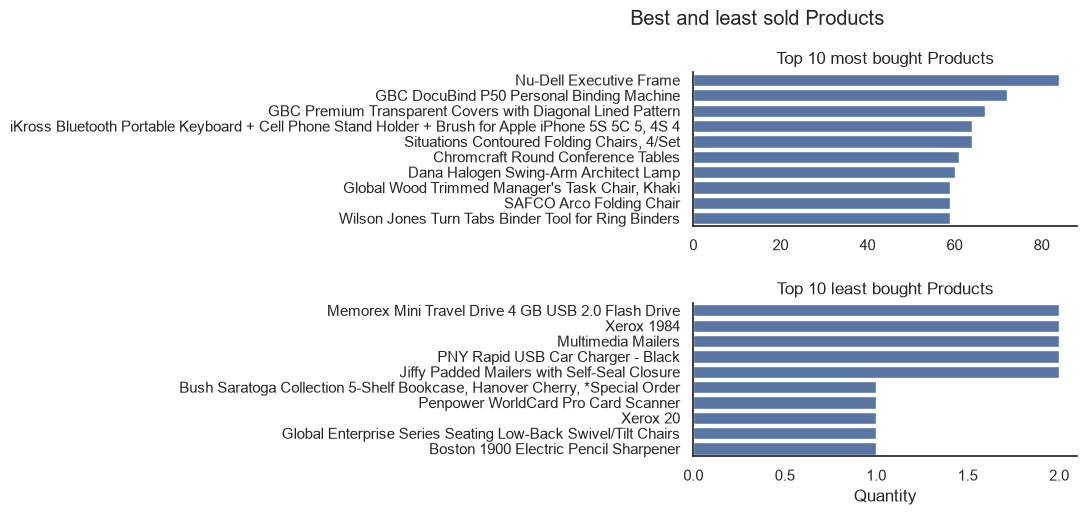

In [58]:
fig, ax = plt.subplots(2, 1)
fig.suptitle('Best and least sold Products')
sns.set_style('white')
sns.despine()

sns.barplot(data=df_best_products, ax=ax[0], x='Total_Quantity', y='Product Name')
ax[0].set_title('Top 10 most bought Products')
ax[0].set_ylabel('')
ax[0].set_xlabel('')

sns.barplot(data=df_worst_products, ax=ax[1], x='Total_Quantity', y='Product Name')
ax[1].set_title('Top 10 least bought Products')
ax[1].set_xlabel('Quantity')
ax[1].set_ylabel('')

plt.subplots_adjust(left=0.4, right=1.00, top=0.85, bottom=0.05, hspace=0.5)
plt.show()